In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

In [3]:
data = "https://raw.githubusercontent.com/ananyaghorpade29/titanic/refs/heads/main/data/Titanic-Dataset.csv"
df = pd.read_csv(data)
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [7]:
x= df.drop(columns=["Name","PassengerId","Ticket","Survived"])
y = df["Survived"]

categorical_col = ["Sex","Embarked"]
numerical_col = ["Age","Pclass","Fare","SibSp","Parch"]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop="first"),categorical_col),
        ("num", "passthrough",numerical_col)
    ]
)

x_train, x_test, y_train, y_test= train_test_split(
    x,y,test_size=0.2, random_state=42, stratify=y
)

Cross-validation + feature importance

In [8]:
#Cross-validation provides a more robust estimate of model performance by reducing variance from a single train-test split
best_pipeline = Pipeline(steps=[
    ("preprocessing",preprocessor),
    ("model", RandomForestClassifier(random_state=42))
])
cv_score = cross_val_score(best_pipeline,x,y, scoring= "accuracy")

print("CV Scores: ", cv_score)
print("Mean Accuracy: ",cv_score.mean())
print("Std Dev: ",cv_score.std())

CV Scores:  [0.78212291 0.80898876 0.83707865 0.76404494 0.84269663]
Mean Accuracy:  0.8069863787583955
Std Dev:  0.030485851094592564


Cross-validation provides a more reliable estimate than a single train-test split.

In [ ]:
best_pipeline.fit(x_train, y_train)
encoded_features= best_pipeline.named_steps['preprocessing'].get_feature_names_out()
importances= best_pipeline.named_steps["model"].feature_importances_


feat_imp = pd.DataFrame({
    "Features": encoded_features,
    "Importances": importances
}).sort_values(by="Importances",ascending=True)

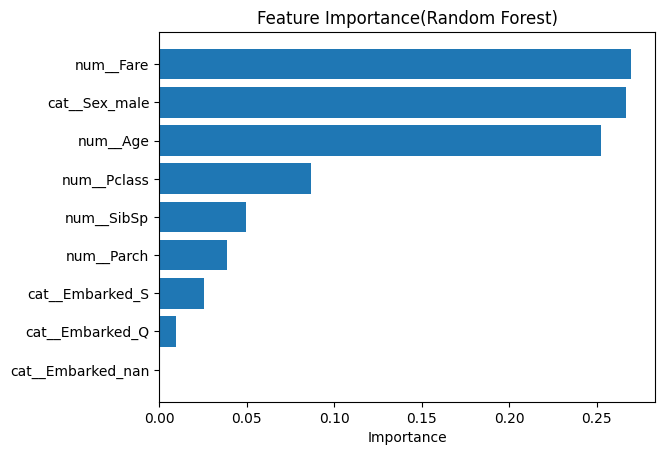

“Features like Embarked and family size have lower importance, 
suggesting they contribute less to prediction compared to core demographic features.


In [11]:
plt.figure()
plt.barh(feat_imp["Features"],feat_imp["Importances"])
plt.xlabel("Importance")
plt.title("Feature Importance(Random Forest)")
plt.show()

print("“Features like Embarked and family size have lower importance, \nsuggesting they contribute less to prediction compared to core demographic features.")

- Fare, Age, and Sex are the most important features
- These align with EDA findings
- Model captures socioeconomic and demographic patterns effectively